In [1]:
# ============================================================
# Phase 1 - Model Comparison and Best Model Selection
# Calorify Visual Food Recognition
# Notebook: Phase1_06_ModelComparison_and_BestModelSelection.ipynb
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import glob
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Main Paths
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/Calorify/phase1_clean"

RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
METADATA_DIR = os.path.join(PROJECT_DIR, "metadata")

COMPARISON_DIR = os.path.join(RESULTS_DIR, "model_comparison")
BEST_MODEL_DIR = os.path.join(MODELS_DIR, "best_model")

os.makedirs(COMPARISON_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Results directory:", RESULTS_DIR)
print("Models directory:", MODELS_DIR)
print("Metadata directory:", METADATA_DIR)
print("Comparison output directory:", COMPARISON_DIR)
print("Best model directory:", BEST_MODEL_DIR)

print("\nFolder checks:")
print("PROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("RESULTS_DIR exists:", os.path.exists(RESULTS_DIR))
print("MODELS_DIR exists:", os.path.exists(MODELS_DIR))
print("METADATA_DIR exists:", os.path.exists(METADATA_DIR))
print("COMPARISON_DIR exists:", os.path.exists(COMPARISON_DIR))
print("BEST_MODEL_DIR exists:", os.path.exists(BEST_MODEL_DIR))

# ============================================================
# Class Names
# ============================================================

class_names_path = os.path.join(METADATA_DIR, "class_names.json")

if os.path.exists(class_names_path):
    with open(class_names_path, "r") as f:
        class_names = json.load(f)

    if isinstance(class_names, dict):
        class_names = [class_names[str(i)] for i in range(len(class_names))]

    print("\nClass names loaded:")
    print(class_names)
    print("Number of classes:", len(class_names))
else:
    class_names = []
    print("\nWARNING: class_names.json not found at:")
    print(class_names_path)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/Calorify/phase1_clean
Results directory: /content/drive/MyDrive/Calorify/phase1_clean/results
Models directory: /content/drive/MyDrive/Calorify/phase1_clean/models
Metadata directory: /content/drive/MyDrive/Calorify/phase1_clean/metadata
Comparison output directory: /content/drive/MyDrive/Calorify/phase1_clean/results/model_comparison
Best model directory: /content/drive/MyDrive/Calorify/phase1_clean/models/best_model

Folder checks:
PROJECT_DIR exists: True
RESULTS_DIR exists: True
MODELS_DIR exists: True
METADATA_DIR exists: True
COMPARISON_DIR exists: True
BEST_MODEL_DIR exists: True

Class names loaded:
['burger', 'pizza', 'fries', 'pasta', 'rice', 'chicken', 'salad', 'sandwich', 'sushi', 'steak']
Number of classes: 10


In [2]:
# ============================================================
# Cell 2 - Find Final Summary Files for All Models
# ============================================================

summary_patterns = [
    "**/*final_summary.csv",
    "**/*_final_summary.csv",
    "**/final_summary.csv",
]

summary_files = []

for pattern in summary_patterns:
    found_files = glob.glob(
        os.path.join(RESULTS_DIR, pattern),
        recursive=True
    )
    summary_files.extend(found_files)

# Remove duplicates and sort
summary_files = sorted(list(set(summary_files)))

print("Number of summary files found:", len(summary_files))
print("\nSummary files:")

for i, file_path in enumerate(summary_files, start=1):
    print(f"{i}. {file_path}")

# Quick preview of each file
print("\nPreview of detected summary files:")

for file_path in summary_files:
    print("\n" + "=" * 100)
    print("File:", file_path)

    try:
        temp_df = pd.read_csv(file_path)
        display(temp_df.head())
        print("Columns:", list(temp_df.columns))
    except Exception as e:
        print("Could not read file:", e)

Number of summary files found: 5

Summary files:
1. /content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_final_summary.csv
2. /content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_final_summary.csv
3. /content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_final_summary.csv
4. /content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_final_summary.csv
5. /content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_final_summary.csv

Preview of detected summary files:

File: /content/drive/MyDrive/Calorify/phase1_clean/results/custom_cnn_final_summary.csv


,model_name,model_type,model_file,history_file,test_accuracy,test_loss,best_validation_accuracy,best_validation_loss,macro_f1_score,weighted_f1_score,correct_predictions,wrong_predictions,status,notes
0,Custom CNN From Scratch,Baseline CNN,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/r...,0.505464,1.521072,0.485636,1.55456,0.494678,0.493573,370,362,Completed,Custom CNN was used as a baseline model. The m...


Columns: ['model_name', 'model_type', 'model_file', 'history_file', 'test_accuracy', 'test_loss', 'best_validation_accuracy', 'best_validation_loss', 'macro_f1_score', 'weighted_f1_score', 'correct_predictions', 'wrong_predictions', 'status', 'notes']

File: /content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_final_summary.csv


,model_name,model_type,training_strategy,weights_file,history_file,test_accuracy,test_loss,best_validation_accuracy,best_validation_loss,best_val_loss_epoch,highest_val_accuracy_epoch,macro_f1_score,weighted_f1_score,correct_predictions,wrong_predictions,status,notes
0,EfficientNetB0 Transfer Learning,Pretrained CNN / Transfer Learning,Frozen EfficientNetB0 base + custom classifica...,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/r...,0.8934,0.3992,0.879617,0.45182,4,7,0.89301,0.893274,654,78,Completed,EfficientNetB0 achieved the best performance s...


Columns: ['model_name', 'model_type', 'training_strategy', 'weights_file', 'history_file', 'test_accuracy', 'test_loss', 'best_validation_accuracy', 'best_validation_loss', 'best_val_loss_epoch', 'highest_val_accuracy_epoch', 'macro_f1_score', 'weighted_f1_score', 'correct_predictions', 'wrong_predictions', 'status', 'notes']

File: /content/drive/MyDrive/Calorify/phase1_clean/results/mobilenetv2_final_summary.csv


...

Columns: ['model_name', 'model_type', 'training_strategy', 'weights_file', 'history_file', 'test_accuracy', 'test_loss', 'best_validation_accuracy', 'best_validation_loss', 'best_epoch', 'macro_f1_score', 'weighted_f1_score', 'correct_predictions', 'wrong_predictions', 'status', 'notes']

File: /content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_final_summary.csv


,model_name,model_type,training_strategy,weights_file,history_file,test_accuracy,test_loss,best_validation_accuracy,best_validation_loss,best_val_loss_epoch,macro_f1_score,weighted_f1_score,correct_predictions,wrong_predictions,status,notes
0,ResNet50 Transfer Learning,Pretrained CNN / Residual Network,Frozen ResNet50 base + custom classification head,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/r...,0.8634,0.4714,0.870041,0.494332,9,0.862754,0.862715,632,100,Completed,ResNet50 achieved strong performance and impro...


Columns: ['model_name', 'model_type', 'training_strategy', 'weights_file', 'history_file', 'test_accuracy', 'test_loss', 'best_validation_accuracy', 'best_validation_loss', 'best_val_loss_epoch', 'macro_f1_score', 'weighted_f1_score', 'correct_predictions', 'wrong_predictions', 'status', 'notes']

File: /content/drive/MyDrive/Calorify/phase1_clean/results/vit/vit_final_summary.csv


,model_name,model_type,training_strategy,weights_file,model_file,history_file,test_accuracy,test_loss,best_validation_accuracy,best_validation_accuracy_epoch,best_validation_loss,best_validation_loss_epoch,macro_f1_score,weighted_f1_score,correct_predictions,wrong_predictions,total_test_samples,status,notes
0,Vision Transformer,Transformer-based Visual Model,ViT trained from scratch using image patches a...,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/r...,0.57377,1.612194,0.511628,20,1.755385,20,0.566844,0.565659,420,312,732,Completed,ViT was included to represent transformer-base...


Columns: ['model_name', 'model_type', 'training_strategy', 'weights_file', 'model_file', 'history_file', 'test_accuracy', 'test_loss', 'best_validation_accuracy', 'best_validation_accuracy_epoch', 'best_validation_loss', 'best_validation_loss_epoch', 'macro_f1_score', 'weighted_f1_score', 'correct_predictions', 'wrong_predictions', 'total_test_samples', 'status', 'notes']


In [3]:
# ============================================================
# Cell 3 - Build Unified Model Comparison Table
# ============================================================

def get_value(row, possible_columns, default=np.nan):
    """
    Safely get a value from a row using multiple possible column names.
    """
    for col in possible_columns:
        if col in row.index:
            return row[col]
    return default


comparison_rows = []

for file_path in summary_files:
    df = pd.read_csv(file_path)

    if df.empty:
        print("Skipping empty summary file:", file_path)
        continue

    row = df.iloc[0]

    model_name = get_value(row, ["model_name"], os.path.basename(file_path))
    model_type = get_value(row, ["model_type"], "Unknown")
    training_strategy = get_value(row, ["training_strategy"], "Not specified")

    test_accuracy = get_value(row, ["test_accuracy"])
    test_loss = get_value(row, ["test_loss"])

    best_validation_accuracy = get_value(
        row,
        [
            "best_validation_accuracy",
            "highest_val_accuracy",
            "highest_validation_accuracy",
            "best_val_accuracy"
        ]
    )

    best_validation_loss = get_value(
        row,
        [
            "best_validation_loss",
            "best_val_loss",
            "lowest_val_loss"
        ]
    )

    macro_f1_score = get_value(
        row,
        [
            "macro_f1_score",
            "macro_f1",
            "macro avg_f1-score"
        ]
    )

    weighted_f1_score = get_value(
        row,
        [
            "weighted_f1_score",
            "weighted_f1",
            "weighted avg_f1-score"
        ]
    )

    correct_predictions = get_value(row, ["correct_predictions"])
    wrong_predictions = get_value(row, ["wrong_predictions"])

    model_file = get_value(row, ["model_file"], "")
    weights_file = get_value(row, ["weights_file"], "")
    history_file = get_value(row, ["history_file"], "")

    notes = get_value(row, ["notes"], "")

    comparison_rows.append({
        "model_name": model_name,
        "model_type": model_type,
        "training_strategy": training_strategy,
        "test_accuracy": float(test_accuracy),
        "test_accuracy_percent": float(test_accuracy) * 100,
        "test_loss": float(test_loss),
        "best_validation_accuracy": float(best_validation_accuracy),
        "best_validation_accuracy_percent": float(best_validation_accuracy) * 100,
        "best_validation_loss": float(best_validation_loss),
        "macro_f1_score": float(macro_f1_score),
        "macro_f1_percent": float(macro_f1_score) * 100,
        "weighted_f1_score": float(weighted_f1_score),
        "weighted_f1_percent": float(weighted_f1_score) * 100,
        "correct_predictions": int(correct_predictions),
        "wrong_predictions": int(wrong_predictions),
        "model_file": model_file,
        "weights_file": weights_file,
        "history_file": history_file,
        "notes": notes,
        "source_summary_file": file_path
    })


comparison_df = pd.DataFrame(comparison_rows)

# Sort by test accuracy first, then macro F1
comparison_df = comparison_df.sort_values(
    by=["test_accuracy", "macro_f1_score"],
    ascending=False
).reset_index(drop=True)

# Add rank
comparison_df.insert(0, "rank", range(1, len(comparison_df) + 1))

comparison_csv_path = os.path.join(
    COMPARISON_DIR,
    "phase1_model_comparison.csv"
)

comparison_df.to_csv(comparison_csv_path, index=False)

print("Unified comparison table saved to:")
print(comparison_csv_path)

display(comparison_df[
    [
        "rank",
        "model_name",
        "model_type",
        "test_accuracy_percent",
        "test_loss",
        "best_validation_accuracy_percent",
        "best_validation_loss",
        "macro_f1_percent",
        "weighted_f1_percent",
        "correct_predictions",
        "wrong_predictions"
    ]
])

Unified comparison table saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/model_comparison/phase1_model_comparison.csv


,rank,model_name,model_type,test_accuracy_percent,test_loss,best_validation_accuracy_percent,best_validation_loss,macro_f1_percent,weighted_f1_percent,correct_predictions,wrong_predictions
0,1,EfficientNetB0 Transfer Learning,Pretrained CNN / Transfer Learning,89.340000,0.399200,87.961700,0.451820,89.301000,89.327400,654,78
1,2,ResNet50 Transfer Learning,Pretrained CNN / Residual Network,86.340000,0.471400,87.004100,0.494332,86.275400,86.271500,632,100
2,3,MobileNetV2 Transfer Learning,Pretrained CNN / Transfer Learning,85.520000,0.476700,85.636100,0.518240,85.543000,85.584100,626,106
3,4,Vision Transformer,Transformer-based Visual Model,57.377046,1.612194,51.162791,1.755385,56.684395,56.565921,420,312
4,5,Custom CNN From Scratch,Baseline CNN,50.546449,1.521072,48.563600,1.554560,49.467800,49.357300,370,362


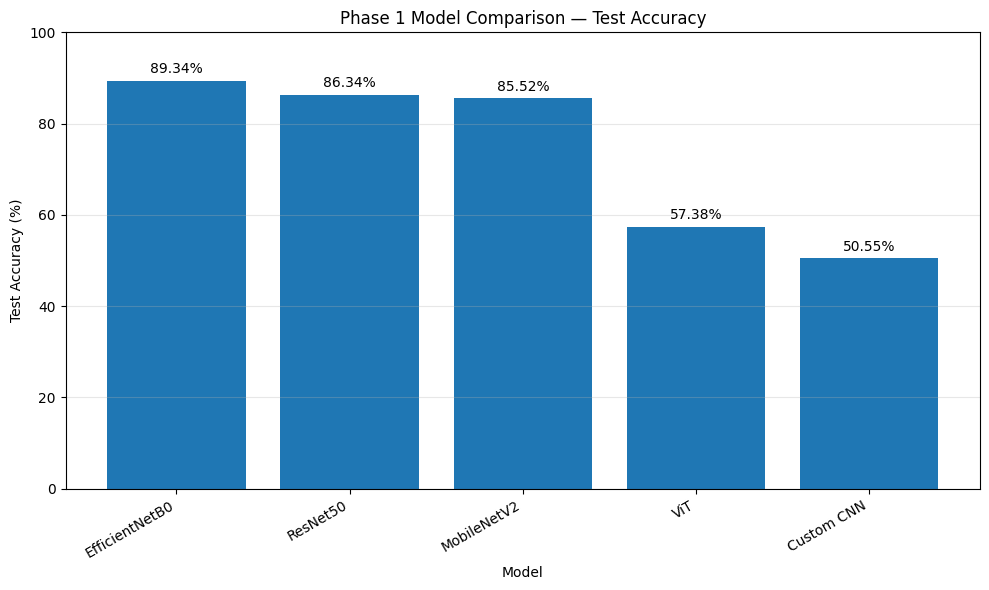

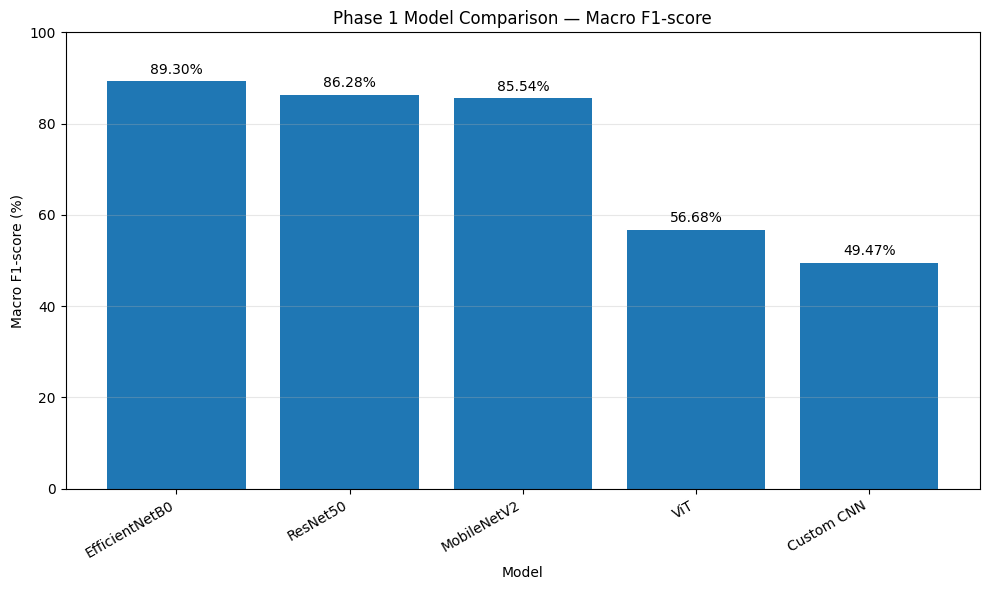

Accuracy comparison plot saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/model_comparison/phase1_test_accuracy_comparison.png

Macro F1 comparison plot saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/model_comparison/phase1_macro_f1_comparison.png


In [4]:
# ============================================================
# Cell 4 - Model Comparison Visualization
# ============================================================

plot_df = comparison_df.copy()

# Short display names
plot_df["display_name"] = plot_df["model_name"].replace({
    "EfficientNetB0 Transfer Learning": "EfficientNetB0",
    "ResNet50 Transfer Learning": "ResNet50",
    "MobileNetV2 Transfer Learning": "MobileNetV2",
    "Vision Transformer": "ViT",
    "Custom CNN From Scratch": "Custom CNN"
})

# ------------------------------------------------------------
# Plot Test Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
bars = plt.bar(
    plot_df["display_name"],
    plot_df["test_accuracy_percent"]
)

plt.title("Phase 1 Model Comparison — Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, plot_df["test_accuracy_percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

accuracy_plot_path = os.path.join(
    COMPARISON_DIR,
    "phase1_test_accuracy_comparison.png"
)

plt.tight_layout()
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Plot Macro F1-score
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
bars = plt.bar(
    plot_df["display_name"],
    plot_df["macro_f1_percent"]
)

plt.title("Phase 1 Model Comparison — Macro F1-score")
plt.xlabel("Model")
plt.ylabel("Macro F1-score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, plot_df["macro_f1_percent"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

f1_plot_path = os.path.join(
    COMPARISON_DIR,
    "phase1_macro_f1_comparison.png"
)

plt.tight_layout()
plt.savefig(f1_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy comparison plot saved to:")
print(accuracy_plot_path)

print("\nMacro F1 comparison plot saved to:")
print(f1_plot_path)

In [5]:
# ============================================================
# Cell 5 - Best Model Selection and Save Best Model Reference
# ============================================================

# Best model is the first row after sorting by test_accuracy and macro_f1_score
best_model_row = comparison_df.iloc[0]

best_model_name = best_model_row["model_name"]
best_model_type = best_model_row["model_type"]
best_test_accuracy = best_model_row["test_accuracy"]
best_macro_f1 = best_model_row["macro_f1_score"]
best_weighted_f1 = best_model_row["weighted_f1_score"]

best_model_file = best_model_row.get("model_file", "")
best_weights_file = best_model_row.get("weights_file", "")
best_history_file = best_model_row.get("history_file", "")
best_summary_file = best_model_row.get("source_summary_file", "")

print("Best Visual Model Selected:")
print("Model name:", best_model_name)
print("Model type:", best_model_type)
print("Test accuracy:", f"{best_test_accuracy * 100:.2f}%")
print("Macro F1-score:", f"{best_macro_f1 * 100:.2f}%")
print("Weighted F1-score:", f"{best_weighted_f1 * 100:.2f}%")

print("\nSource files:")
print("Model file:", best_model_file)
print("Weights file:", best_weights_file)
print("History file:", best_history_file)
print("Summary file:", best_summary_file)

# ------------------------------------------------------------
# Create best model info
# ------------------------------------------------------------

best_model_info = {
    "best_visual_model": best_model_name,
    "model_type": best_model_type,
    "selection_reason": [
        "Highest test accuracy among all Phase 1 models",
        "Highest macro F1-score among all Phase 1 models",
        "Highest weighted F1-score among all Phase 1 models",
        "Lowest number of wrong predictions",
        "Best balance between performance and validation stability"
    ],
    "test_accuracy": float(best_test_accuracy),
    "test_accuracy_percent": float(best_test_accuracy * 100),
    "macro_f1_score": float(best_macro_f1),
    "macro_f1_percent": float(best_macro_f1 * 100),
    "weighted_f1_score": float(best_weighted_f1),
    "weighted_f1_percent": float(best_weighted_f1 * 100),
    "source_model_file": str(best_model_file),
    "source_weights_file": str(best_weights_file),
    "source_history_file": str(best_history_file),
    "source_summary_file": str(best_summary_file),
    "final_decision": (
        "EfficientNetB0 was selected as the final visual food classifier "
        "for the Calorify pipeline because it achieved the best overall "
        "test accuracy and F1 performance across all Phase 1 experiments."
    )
}

# Save JSON
best_model_info_json_path = os.path.join(
    BEST_MODEL_DIR,
    "best_food_classifier_info.json"
)

with open(best_model_info_json_path, "w") as f:
    json.dump(best_model_info, f, indent=4)

# Save TXT
best_model_summary_txt_path = os.path.join(
    COMPARISON_DIR,
    "phase1_best_model_summary.txt"
)

with open(best_model_summary_txt_path, "w") as f:
    f.write("Phase 1 Best Model Selection Summary\n")
    f.write("=" * 45 + "\n\n")
    for key, value in best_model_info.items():
        f.write(f"{key}: {value}\n")

# Save CSV
best_model_summary_csv_path = os.path.join(
    COMPARISON_DIR,
    "phase1_best_model_summary.csv"
)

pd.DataFrame([best_model_info]).to_csv(best_model_summary_csv_path, index=False)

print("\nBest model info saved to:")
print(best_model_info_json_path)
print(best_model_summary_txt_path)
print(best_model_summary_csv_path)

# ------------------------------------------------------------
# Copy best model / weights to stable reference names
# ------------------------------------------------------------

stable_model_path = os.path.join(BEST_MODEL_DIR, "best_food_classifier.keras")
stable_weights_path = os.path.join(BEST_MODEL_DIR, "best_food_classifier.weights.h5")
stable_class_names_path = os.path.join(BEST_MODEL_DIR, "class_names.json")

copied_any_model_file = False

# Copy full .keras model if available
if isinstance(best_model_file, str) and os.path.exists(best_model_file):
    shutil.copy2(best_model_file, stable_model_path)
    print("\nCopied best .keras model to:")
    print(stable_model_path)
    copied_any_model_file = True
else:
    print("\nNo valid full .keras model file found to copy.")

# Copy weights if available
if isinstance(best_weights_file, str) and os.path.exists(best_weights_file):
    shutil.copy2(best_weights_file, stable_weights_path)
    print("\nCopied best weights to:")
    print(stable_weights_path)
    copied_any_model_file = True
else:
    print("\nNo valid weights file found to copy.")

# Copy class names
if os.path.exists(class_names_path):
    shutil.copy2(class_names_path, stable_class_names_path)
    print("\nCopied class names to:")
    print(stable_class_names_path)

if not copied_any_model_file:
    print("\nWARNING: No model or weights file was copied.")
    print("Check EfficientNetB0 summary paths manually.")

print("\nBest model selection step completed.")

Best Visual Model Selected:
Model name: EfficientNetB0 Transfer Learning
Model type: Pretrained CNN / Transfer Learning
Test accuracy: 89.34%
Macro F1-score: 89.30%
Weighted F1-score: 89.33%

Source files:
Model file: 
Weights file: /content/drive/MyDrive/Calorify/phase1_clean/models/efficientnetb0_transfer_learning.weights.h5
History file: /content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_history.csv
Summary file: /content/drive/MyDrive/Calorify/phase1_clean/results/efficientnetb0_final_summary.csv

Best model info saved to:
/content/drive/MyDrive/Calorify/phase1_clean/models/best_model/best_food_classifier_info.json
/content/drive/MyDrive/Calorify/phase1_clean/results/model_comparison/phase1_best_model_summary.txt
/content/drive/MyDrive/Calorify/phase1_clean/results/model_comparison/phase1_best_model_summary.csv

No valid full .keras model file found to copy.

Copied best weights to:
/content/drive/MyDrive/Calorify/phase1_clean/models/best_model/best_food_classifier

In [6]:
# ============================================================
# Cell 6 - Verify Final Phase 1 Output Files
# ============================================================

expected_files = {
    "Model comparison CSV": os.path.join(COMPARISON_DIR, "phase1_model_comparison.csv"),
    "Accuracy comparison plot": os.path.join(COMPARISON_DIR, "phase1_test_accuracy_comparison.png"),
    "Macro F1 comparison plot": os.path.join(COMPARISON_DIR, "phase1_macro_f1_comparison.png"),
    "Best model summary TXT": os.path.join(COMPARISON_DIR, "phase1_best_model_summary.txt"),
    "Best model summary CSV": os.path.join(COMPARISON_DIR, "phase1_best_model_summary.csv"),
    "Best model info JSON": os.path.join(BEST_MODEL_DIR, "best_food_classifier_info.json"),
    "Best model weights": os.path.join(BEST_MODEL_DIR, "best_food_classifier.weights.h5"),
    "Best model class names": os.path.join(BEST_MODEL_DIR, "class_names.json"),
}

verification_rows = []

for file_label, file_path in expected_files.items():
    exists = os.path.exists(file_path)
    size_mb = os.path.getsize(file_path) / (1024 * 1024) if exists else 0

    verification_rows.append({
        "file_label": file_label,
        "file_path": file_path,
        "exists": exists,
        "size_mb": round(size_mb, 4)
    })

verification_df = pd.DataFrame(verification_rows)

verification_path = os.path.join(
    COMPARISON_DIR,
    "phase1_output_verification.csv"
)

verification_df.to_csv(verification_path, index=False)

print("Phase 1 output verification saved to:")
print(verification_path)

display(verification_df)

missing_files = verification_df[verification_df["exists"] == False]

if len(missing_files) == 0:
    print("\nAll required Phase 1 final output files exist.")
else:
    print("\nWARNING: Some files are missing:")
    display(missing_files)

Phase 1 output verification saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/model_comparison/phase1_output_verification.csv


,file_label,file_path,exists,size_mb
0,Model comparison CSV,/content/drive/MyDrive/Calorify/phase1_clean/r...,True,0.0046
1,Accuracy comparison plot,/content/drive/MyDrive/Calorify/phase1_clean/r...,True,0.1582
2,Macro F1 comparison plot,/content/drive/MyDrive/Calorify/phase1_clean/r...,True,0.1588
3,Best model summary TXT,/content/drive/MyDrive/Calorify/phase1_clean/r...,True,0.0011
4,Best model summary CSV,/content/drive/MyDrive/Calorify/phase1_clean/r...,True,0.0010
5,Best model info JSON,/content/drive/MyDrive/Calorify/phase1_clean/m...,True,0.0012
6,Best model weights,/content/drive/MyDrive/Calorify/phase1_clean/m...,True,19.8519
7,Best model class names,/content/drive/MyDrive/Calorify/phase1_clean/m...,True,0.0001



All required Phase 1 final output files exist.


In [7]:
# Final Summary — Phase 1 Model Comparison and Best Model Selection
#
# In this notebook, all Phase 1 visual food recognition models were compared using the same test set and evaluation metrics.
#
# Models Compared
#
# 1. Custom CNN from Scratch
# 2. MobileNetV2 Transfer Learning
# 3. EfficientNetB0 Transfer Learning
# 4. ResNet50 Transfer Learning
# 5. Vision Transformer
#
# Final Ranking
#
# 1. EfficientNetB0
#    - Test Accuracy: 89.34%
#    - Macro F1-score: 89.30%
#    - Weighted F1-score: 89.33%
#
# 2. ResNet50
#    - Test Accuracy: 86.34%
#    - Macro F1-score: 86.28%
#    - Weighted F1-score: 86.27%
#
# 3. MobileNetV2
#    - Test Accuracy: 85.52%
#    - Macro F1-score: 85.54%
#    - Weighted F1-score: 85.58%
#
# 4. Vision Transformer
#    - Test Accuracy: 57.38%
#    - Macro F1-score: 56.68%
#    - Weighted F1-score: 56.57%
#
# 5. Custom CNN
#    - Test Accuracy: 50.55%
#    - Macro F1-score: 49.47%
#    - Weighted F1-score: 49.36%
#
# Best Visual Model Selected
#
# EfficientNetB0 was selected as the final visual food classifier for the Calorify pipeline.
#
# Selection Reasons
#
# - It achieved the highest test accuracy among all Phase 1 models.
# - It achieved the highest macro F1-score.
# - It achieved the highest weighted F1-score.
# - It had the lowest number of wrong predictions.
# - It showed the best balance between accuracy, generalization, and training stability.
#
# Interpretation
#
# The pretrained CNN models significantly outperformed the custom CNN baseline.
# EfficientNetB0 achieved the strongest overall performance, followed by ResNet50 and MobileNetV2.
#
# The Vision Transformer experiment was successfully completed as a transformer-based visual model.
# However, it performed lower than pretrained CNN models because it was trained from scratch on a relatively small dataset.
# This result is expected and provides an important architectural comparison between CNN-based and transformer-based visual models.
#
# Final Phase 1 Output Files
#
# The following final files were created:
#
# - phase1_model_comparison.csv
# - phase1_test_accuracy_comparison.png
# - phase1_macro_f1_comparison.png
# - phase1_best_model_summary.txt
# - phase1_best_model_summary.csv
# - best_food_classifier_info.json
# - best_food_classifier.weights.h5
# - class_names.json
#
# Conclusion
#
# Phase 1 is officially completed.
# The final selected image classification model for the Calorify pipeline is EfficientNetB0.